# Heart Disease (Cleveland)  -  Exploratory Data Analysis

Dataset: UCI Heart Disease (id=45), Cleveland subset  -  303 patients, 13
clinical features, target binarized (0 = no disease, 1 = disease present).
Theme: **clinical risk stratification**  -  beyond overall patterns, how does
risk differ across patient subgroups (sex, age band, symptom presentation)?

All figures are saved to `docs/figures/eda/` for the final report.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd()
if not (ROOT / "data").exists():          # running from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ml.data.preprocess import CATEGORICAL_COLS, CONTINUOUS_COLS, TARGET_COL

FIG_DIR = ROOT / "docs" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Fixed, CVD-validated palette (see docs/DECISIONS.md).
C_NO, C_YES = "#2a78d6", "#e34948"        # no disease / disease
TARGET_PALETTE = {0: C_NO, 1: C_YES}
DIVERGING = LinearSegmentedColormap.from_list("div", [C_NO, "#f0efec", C_YES])
SEQ_BLUE = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#0d366b"])

sns.set_theme(
    style="whitegrid",
    rc={
        "axes.edgecolor": "#c3c2b7",
        "grid.color": "#e1e0d9",
        "axes.labelcolor": "#52514e",
        "text.color": "#0b0b0b",
        "xtick.color": "#898781",
        "ytick.color": "#898781",
    },
)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


raw = pd.read_csv(ROOT / "data" / "raw" / "heart_cleveland_raw.csv")
clean = pd.read_csv(ROOT / "data" / "processed" / "heart_cleveland_clean.csv")
print(f"raw: {raw.shape}, clean: {clean.shape}")

raw: (303, 14), clean: (297, 14)


## 1. Data overview

In [2]:
clean.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [3]:
clean[CONTINUOUS_COLS + [TARGET_COL]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2
target,297.0,0.461279,0.499340,0.0,0.0,0.0,1.0,1.0


In [4]:
clean[CATEGORICAL_COLS].astype("object").describe().T

,count,unique,top,freq
sex,297,2,1,201
cp,297,4,4,142
fbs,297,2,0,254
restecg,297,3,0,147
exang,297,2,0,200
slope,297,3,1,139
ca,297,4,0,174
thal,297,3,3,164


## 2. Missing-value analysis (raw data)

The cleaned data has no missing values by construction; missingness is a
property of the *raw* data: `ca` (fluoroscopy vessel count) and `thal`
(thalassemia type)  -  likely tests not performed for those patients.
Decision: drop the 6 affected rows (2% of data) rather than impute
categorical clinical measurements. See docs/DECISIONS.md.

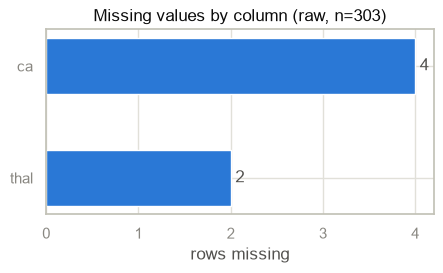

In [5]:
missing = raw.isna().sum()
missing = missing[missing > 0]
fig, ax = plt.subplots(figsize=(5, 2.4))
ax.barh(missing.index[::-1], missing.values[::-1], color=C_NO, height=0.5)
ax.set_xlabel("rows missing")
ax.set_title(f"Missing values by column (raw, n={len(raw)})")
for i, v in enumerate(missing.values[::-1]):
    ax.text(v + 0.05, i, str(v), va="center", color="#52514e")
save_fig(fig, "missingness")
plt.show()

## 3. Class balance

Left: the raw target is severity 0–4. Right: the binarized target used for
modeling  -  near-balanced, so accuracy is meaningful and no resampling is
needed (though we still report precision/recall/ROC-AUC).

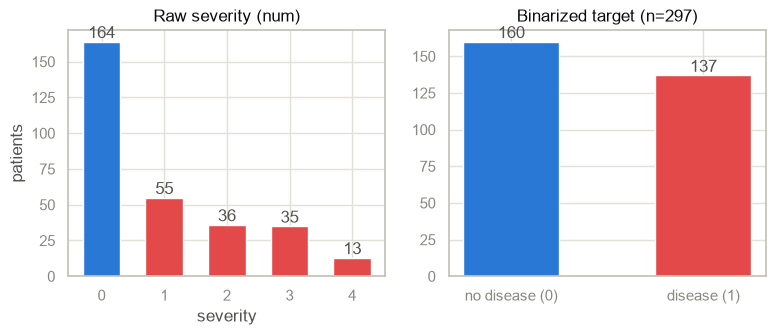

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
sev_counts = raw["num"].value_counts().sort_index()
sev_colors = [C_NO] + [C_YES] * 4
axes[0].bar(sev_counts.index.astype(str), sev_counts.values, color=sev_colors, width=0.6)
axes[0].set_title("Raw severity (num)")
axes[0].set_xlabel("severity")
axes[0].set_ylabel("patients")
bin_counts = clean[TARGET_COL].value_counts().sort_index()
axes[1].bar(["no disease (0)", "disease (1)"], bin_counts.values, color=[C_NO, C_YES], width=0.5)
axes[1].set_title(f"Binarized target (n={len(clean)})")
for ax in axes:
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", color="#52514e")
save_fig(fig, "class_balance")
plt.show()

## 4. Feature distributions by target

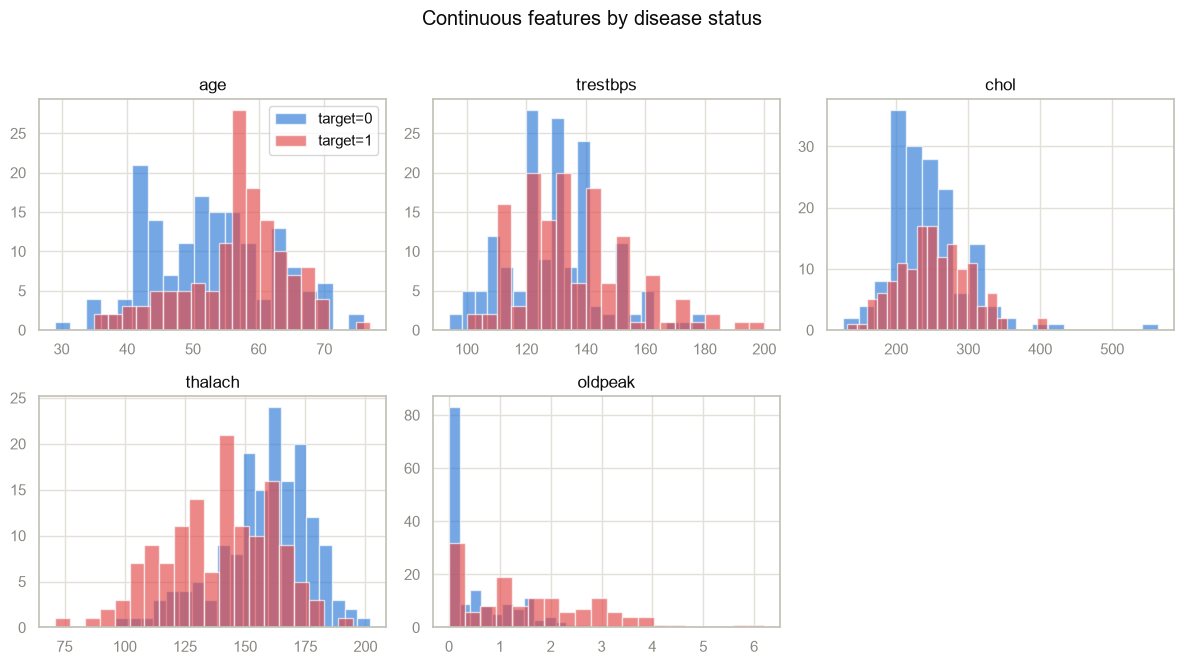

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, col in zip(axes.flat, CONTINUOUS_COLS):
    for t in (0, 1):
        ax.hist(clean.loc[clean[TARGET_COL] == t, col], bins=20, alpha=0.65,
                color=TARGET_PALETTE[t], label=f"target={t}")
    ax.set_title(col)
axes.flat[-1].axis("off")
axes.flat[0].legend()
fig.suptitle("Continuous features by disease status", y=1.02)
fig.tight_layout()
save_fig(fig, "continuous_distributions")
plt.show()

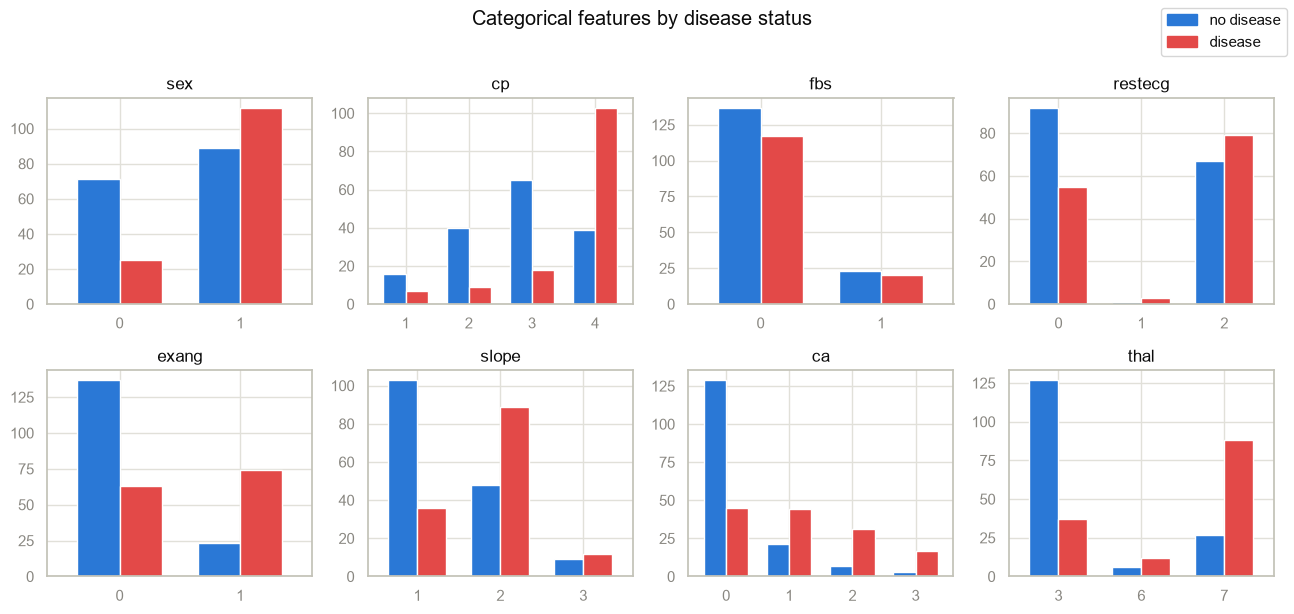

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for ax, col in zip(axes.flat, CATEGORICAL_COLS):
    ct = clean.groupby([col, TARGET_COL]).size().unstack(fill_value=0)
    ct.plot(kind="bar", ax=ax, color=[C_NO, C_YES], width=0.7, legend=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (C_NO, C_YES)]
fig.legend(handles, ["no disease", "disease"], loc="upper right")
fig.suptitle("Categorical features by disease status", y=1.02)
fig.tight_layout()
save_fig(fig, "categorical_distributions")
plt.show()

## 5. Correlation heatmap

Pearson correlations among continuous features plus the binary target
(point-biserial). Diverging scale: blue = negative, red = positive.

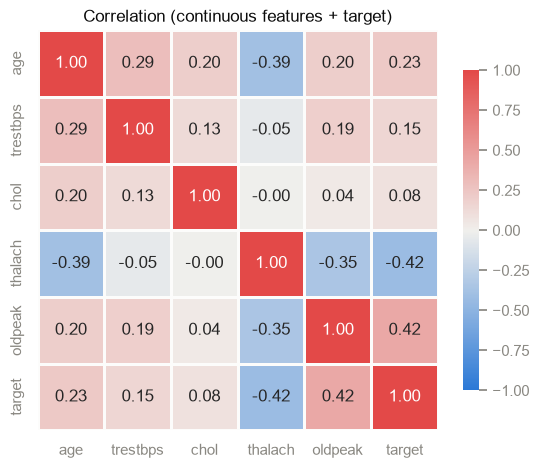

In [9]:
corr = clean[CONTINUOUS_COLS + [TARGET_COL]].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, linecolor="#fcfcfb",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation (continuous features + target)")
save_fig(fig, "correlation_heatmap")
plt.show()

## 6. Risk stratification: subgroup analysis

The clinical angle of this project  -  disease prevalence is not uniform
across patient subgroups.

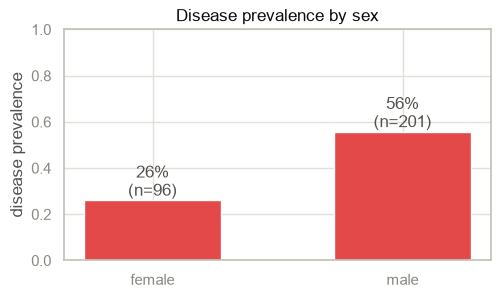

In [10]:
def prevalence_bar(series_by, title, fname, labels=None):
    prev = clean.groupby(series_by)[TARGET_COL].mean()
    n = clean.groupby(series_by)[TARGET_COL].size()
    fig, ax = plt.subplots(figsize=(5.5, 3))
    x = [str(i) if labels is None else labels[i] for i in prev.index]
    ax.bar(x, prev.values, color=C_YES, width=0.55)
    ax.set_ylabel("disease prevalence")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    for i, (p, cnt) in enumerate(zip(prev.values, n.values)):
        ax.text(i, p + 0.02, f"{p:.0%}\n(n={cnt})", ha="center", color="#52514e")
    save_fig(fig, fname)
    plt.show()


prevalence_bar("sex", "Disease prevalence by sex", "prevalence_by_sex",
               labels={0: "female", 1: "male"})

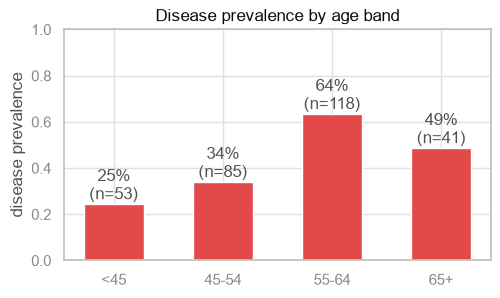

In [11]:
clean["age_band"] = pd.cut(clean["age"], bins=[0, 45, 55, 65, 120],
                           labels=["<45", "45-54", "55-64", "65+"], right=False)
prev = clean.groupby("age_band", observed=True)[TARGET_COL].mean()
n = clean.groupby("age_band", observed=True)[TARGET_COL].size()
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.bar(prev.index.astype(str), prev.values, color=C_YES, width=0.55)
ax.set_ylabel("disease prevalence")
ax.set_ylim(0, 1)
ax.set_title("Disease prevalence by age band")
for i, (p, cnt) in enumerate(zip(prev.values, n.values)):
    ax.text(i, p + 0.02, f"{p:.0%}\n(n={cnt})", ha="center", color="#52514e")
save_fig(fig, "prevalence_by_age_band")
plt.show()
clean = clean.drop(columns=["age_band"])

### Chest-pain type × exercise-induced angina

cp: 1 = typical angina, 2 = atypical angina, 3 = non-anginal pain,
4 = asymptomatic. exang: exercise-induced angina (0/1).

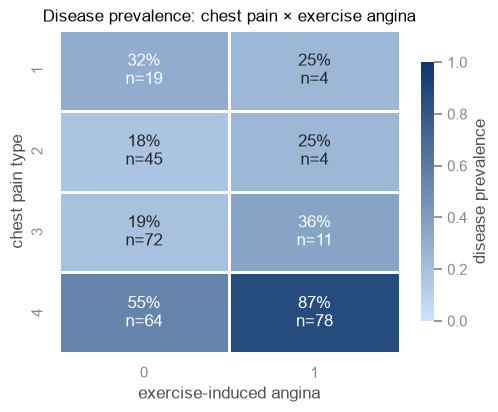

In [12]:
pivot = clean.pivot_table(index="cp", columns="exang", values=TARGET_COL, aggfunc="mean")
counts = clean.pivot_table(index="cp", columns="exang", values=TARGET_COL, aggfunc="size")
annot = pivot.copy().astype(object)
for r in pivot.index:
    for c in pivot.columns:
        annot.loc[r, c] = f"{pivot.loc[r, c]:.0%}\nn={counts.loc[r, c]:.0f}"
fig, ax = plt.subplots(figsize=(5.5, 4.2))
sns.heatmap(pivot, annot=annot, fmt="", cmap=SEQ_BLUE, vmin=0, vmax=1,
            linewidths=1, linecolor="#fcfcfb",
            cbar_kws={"label": "disease prevalence", "shrink": 0.8}, ax=ax)
ax.set_xlabel("exercise-induced angina")
ax.set_ylabel("chest pain type")
ax.set_title("Disease prevalence: chest pain × exercise angina")
save_fig(fig, "cp_exang_prevalence")
plt.show()

## 7. Findings summary

(Bullets below are verified against the executed outputs above.)

- **Class balance**: the binarized target is near-balanced  -  160 no-disease
  (54%) vs 137 disease (46%) of n=297  -  down from the raw severity spread
  (num=0..4: 164/55/36/35/13). Accuracy is a meaningful metric here, though
  precision/recall/ROC-AUC are still reported.
- **Missing-data decision**: only `ca` (4 rows) and `thal` (2 rows) have
  missing values in the raw data  -  6 rows total, ~2% of the 303-patient raw
  set  -  dropped rather than imputing categorical clinical measurements
  (see docs/DECISIONS.md).
- **Sex prevalence gap**: males show more than double the disease
  prevalence of females  -  56% (n=201) vs 26% (n=96).
- **Age-band trend**: prevalence rises with age from 25% (<45, n=53) to 34%
  (45-54, n=85) to a peak of 64% (55-64, n=118), then falls to 49% (65+,
  n=41)  -  the drop in the oldest band is likely a small-sample effect
  rather than a true risk decline.
- **cp × exang / "asymptomatic" pattern**: chest-pain type 4 (labeled
  *asymptomatic*) has by far the highest prevalence in the grid  -  55%
  without exercise angina (n=64) and 87% with it (n=78)  -  versus 18-36%
  for symptomatic types 1-3. The asymptomatic label is counterintuitive:
  it marks the highest-risk group, especially combined with exang=1.
- **Strongest correlates of target**: among continuous features, `oldpeak`
  (ST depression) has the strongest positive correlation with target
  (r=0.42) and `thalach` (max heart rate achieved) the strongest negative
  (r=-0.42); `age` is a weaker positive correlate (r=0.23).
- **Clinical read**: `cp`, `exang`, `oldpeak`, `thalach`, `sex`, and `age`
  stand out as high-signal features for risk stratification and should be
  inspected closely during feature importance / model interpretation.

In [13]:
print("EDA complete; figures written to", FIG_DIR)

EDA complete; figures written to C:\Users\adith\OneDrive\Desktop\MTech\MLOPS\assignment_1\heart-disease-mlops\docs\figures\eda
